<a href="https://www.kaggle.com/code/sonawanelalitsunil/global-recipe-collection-ml?scriptVersionId=236298973" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/collection-of-recipes-around-the-world/Receipes from around the world.csv


## Title :Global Recipe Collection

## Description:
A curated journey of flavors from around the world, featuring authentic recipes from every corner of the globe.

Would you like a few more variations depending on the vibe you're aiming for? 🌎🍴










## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/collection-of-recipes-around-the-world/Receipes from around the world.csv', encoding='ISO-8859-1')


In [3]:
df.head()

,recipe_name,cuisine,ingredients,cooking_time_minutes,prep_time_minutes,servings,calories_per_serving,dietary_restrictions
0,Spicy Kimchi Fried Rice,Korean,"['Cooked rice', 'Kimchi', 'Gochujang', 'Soy sa...",25,15,2.0,450.0,['vegetarian']
1,Classic Margherita Pizza,Italian,"['Pizza dough', 'Tomato sauce', 'Fresh mozzare...",20,30,4.0,350.0,['vegetarian']
2,Coconut Chickpea Curry,Indian,"['Chickpeas', 'Coconut milk', 'Onion', 'Ginger...",35,15,4.0,480.0,"['vegan', 'vegetarian', 'gluten-free', 'dairy-..."
3,Pad See Ew with Tofu,Thai,"['Wide rice noodles', 'Tofu', 'Chinese broccol...",20,10,2.0,520.0,['vegetarian']
4,Beef Bourguignon,French,"['Beef chuck', 'Red wine', 'Bacon', 'Onion', '...",150,30,6.0,680.0,['nan']


In [4]:
df.tail()

,recipe_name,cuisine,ingredients,cooking_time_minutes,prep_time_minutes,servings,calories_per_serving,dietary_restrictions
156,Thai Lime Grill,Thai,"['lime', 'basil', 'lemongrass', 'peanuts', 'ch...",90,10,2.0,229.0,['nan']
157,Korean Scallions Delight,Korean,"['garlic', 'sesame oil', 'soy sauce', 'gochuja...",86,7,6.0,437.0,['vegan']
158,Nigerian Cassava Feast,Nigerian,"['palm oil', 'okra', 'egusi', 'cassava', 'yams...",39,44,3.0,389.0,['nan']
159,American Corn Curry,American,"['bacon', 'beef', 'mustard', 'corn', 'cheddar']",58,30,1.0,749.0,['nan']
160,Brazilian BlackBeans Curry,Brazilian,"['black beans', 'cassava', 'collard greens', '...",65,21,3.0,321.0,['vegetarian']


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161 entries, 0 to 160
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   recipe_name           161 non-null    object 
 1   cuisine               161 non-null    object 
 2   ingredients           161 non-null    object 
 3   cooking_time_minutes  161 non-null    int64  
 4   prep_time_minutes     161 non-null    int64  
 5   servings              157 non-null    float64
 6   calories_per_serving  156 non-null    float64
 7   dietary_restrictions  161 non-null    object 
dtypes: float64(2), int64(2), object(4)
memory usage: 10.2+ KB


In [6]:
df.isnull().sum()

recipe_name             0
cuisine                 0
ingredients             0
cooking_time_minutes    0
prep_time_minutes       0
servings                4
calories_per_serving    5
dietary_restrictions    0
dtype: int64

In [7]:
df.duplicated().sum()

0

In [8]:
df.shape

(161, 8)

In [9]:
df.dtypes

recipe_name              object
cuisine                  object
ingredients              object
cooking_time_minutes      int64
prep_time_minutes         int64
servings                float64
calories_per_serving    float64
dietary_restrictions     object
dtype: object

In [10]:
df.columns

Index(['recipe_name', 'cuisine', 'ingredients', 'cooking_time_minutes',
       'prep_time_minutes', 'servings', 'calories_per_serving',
       'dietary_restrictions'],
      dtype='object')

## Data visualizations

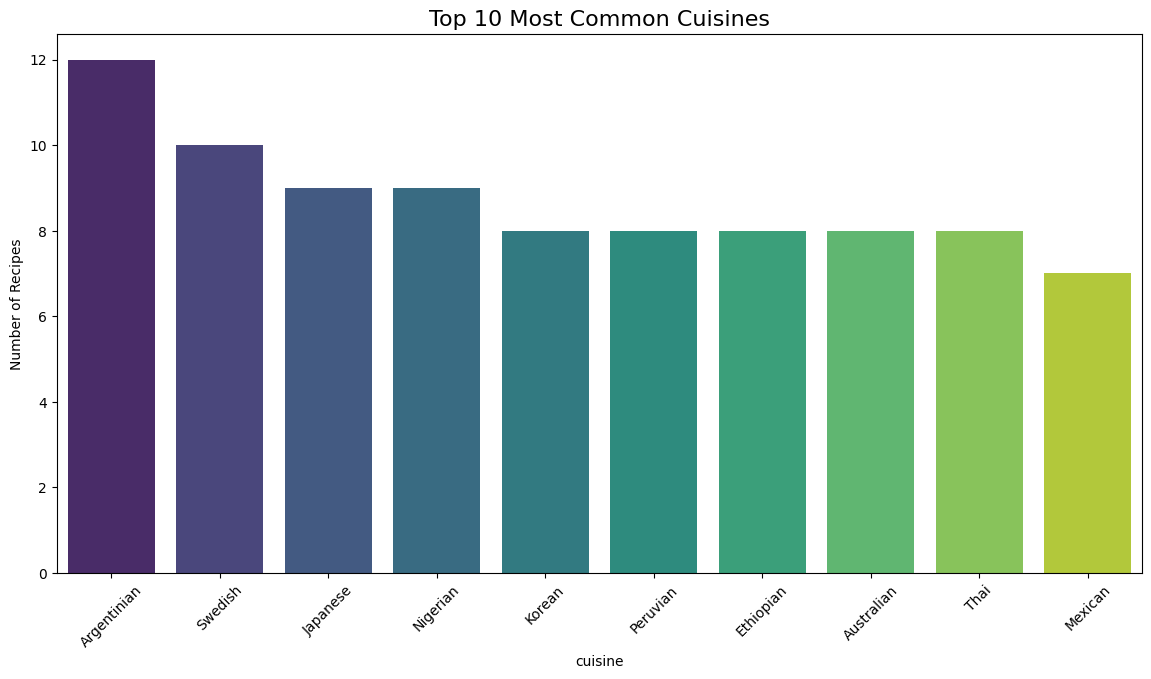

In [11]:
# 1. Cuisine Distribution
plt.figure(figsize=(14, 7))
top_cuisines = df['cuisine'].value_counts().head(10)
sns.barplot(x=top_cuisines.index, y=top_cuisines.values, palette='viridis')
plt.title('Top 10 Most Common Cuisines', fontsize=16)
plt.ylabel('Number of Recipes')
plt.xticks(rotation=45)
plt.show()

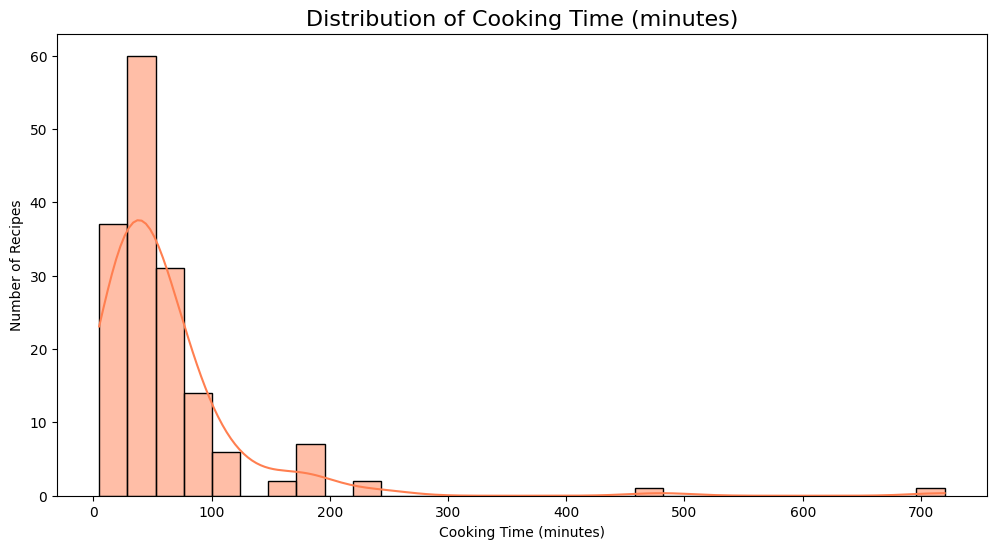

In [12]:
# 2. Cooking Time Distribution
plt.figure(figsize=(12, 6))
sns.histplot(df['cooking_time_minutes'].dropna(), bins=30, kde=True, color='coral')
plt.title('Distribution of Cooking Time (minutes)', fontsize=16)
plt.xlabel('Cooking Time (minutes)')
plt.ylabel('Number of Recipes')
plt.show()

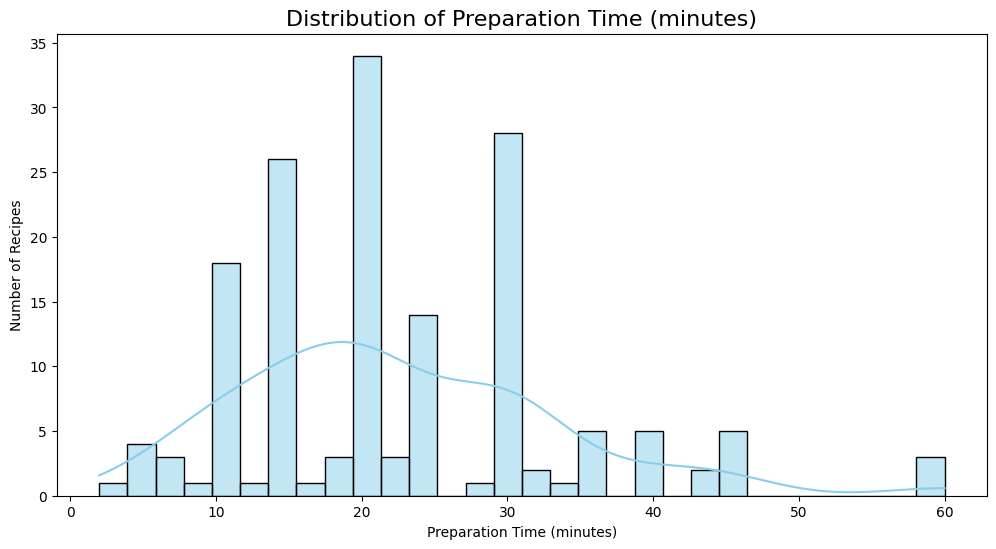

In [13]:
# 3. Prep Time Distribution
plt.figure(figsize=(12, 6))
sns.histplot(df['prep_time_minutes'].dropna(), bins=30, kde=True, color='skyblue')
plt.title('Distribution of Preparation Time (minutes)', fontsize=16)
plt.xlabel('Preparation Time (minutes)')
plt.ylabel('Number of Recipes')
plt.show()

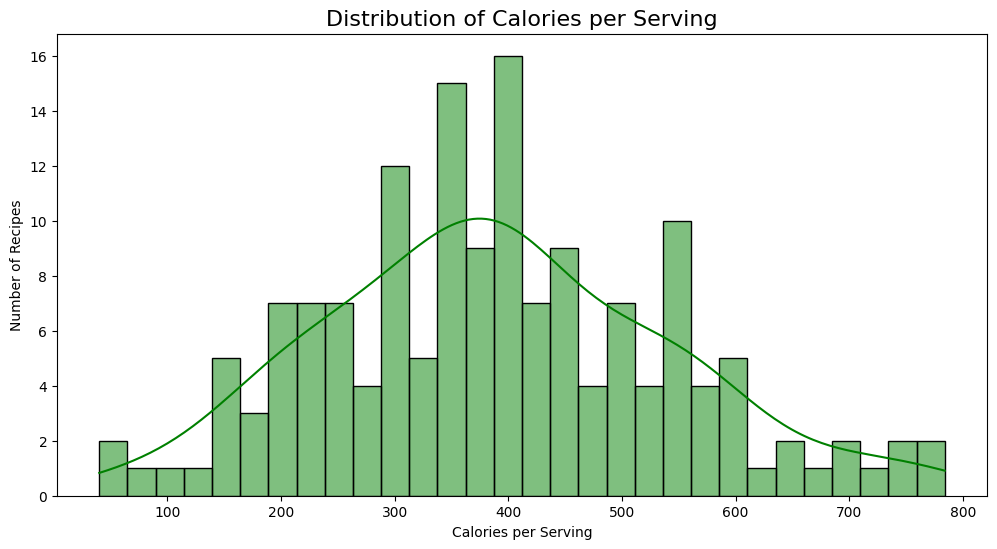

In [14]:
# 4. Calories per Serving
plt.figure(figsize=(12, 6))
sns.histplot(df['calories_per_serving'].dropna(), bins=30, kde=True, color='green')
plt.title('Distribution of Calories per Serving', fontsize=16)
plt.xlabel('Calories per Serving')
plt.ylabel('Number of Recipes')
plt.show()

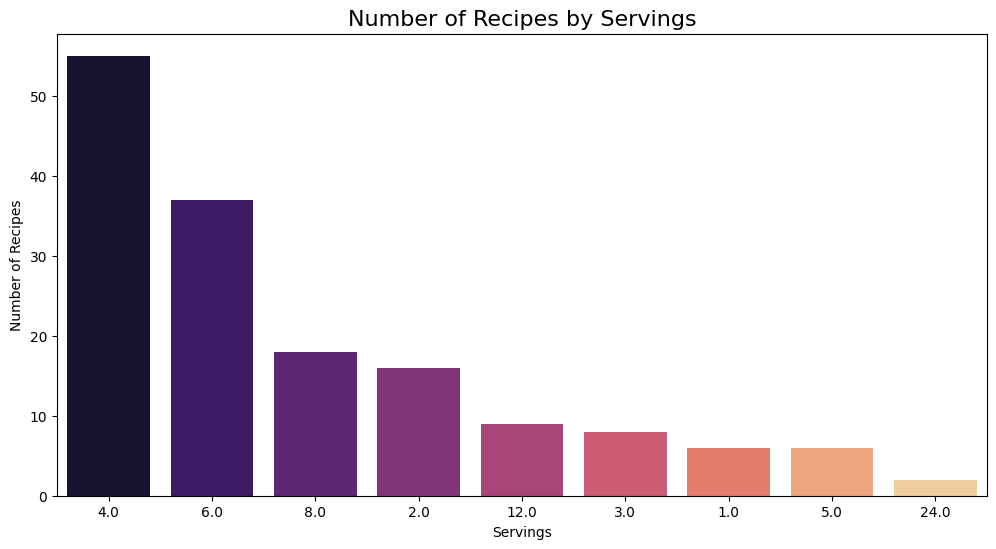

In [15]:
# 5. Servings Count
plt.figure(figsize=(12, 6))
sns.countplot(x='servings', data=df, palette='magma', order=df['servings'].value_counts().index)
plt.title('Number of Recipes by Servings', fontsize=16)
plt.xlabel('Servings')
plt.ylabel('Number of Recipes')
plt.show()


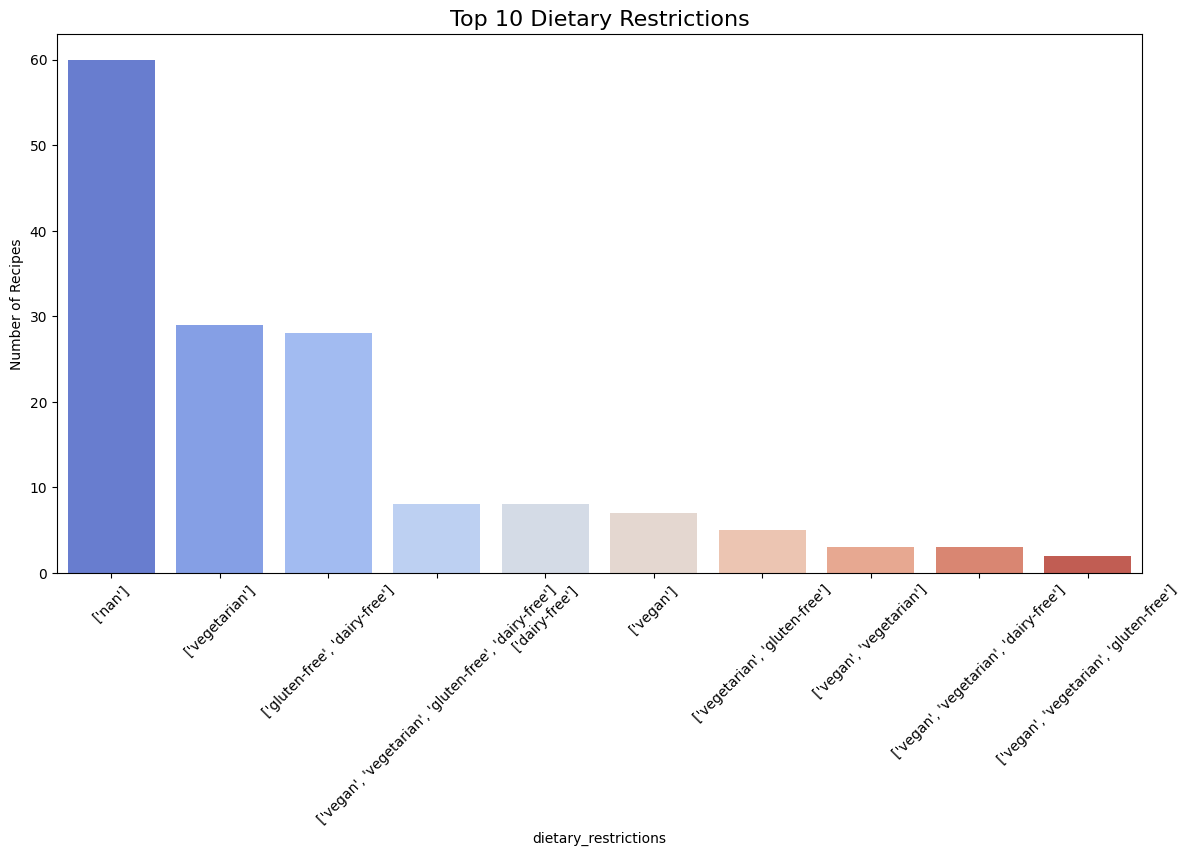

In [16]:
# 6. Dietary Restrictions
plt.figure(figsize=(14, 7))
top_dietary = df['dietary_restrictions'].value_counts().head(10)
sns.barplot(x=top_dietary.index, y=top_dietary.values, palette='coolwarm')
plt.title('Top 10 Dietary Restrictions', fontsize=16)
plt.ylabel('Number of Recipes')
plt.xticks(rotation=45)
plt.show()

## Predictive modeling

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

In [18]:
# Selecting columns
columns_needed = ['cuisine', 'ingredients', 'cooking_time_minutes', 'prep_time_minutes', 
                  'servings', 'calories_per_serving', 'dietary_restrictions']

df = df[columns_needed]

# Fill missing values
df.fillna({
    'cooking_time_minutes': df['cooking_time_minutes'].median(),
    'prep_time_minutes': df['prep_time_minutes'].median(),
    'servings': df['servings'].mode()[0],
    'calories_per_serving': df['calories_per_serving'].median(),
    'dietary_restrictions': 'None'
}, inplace=True)

# Encoding categorical columns
label_encoders = {}

for col in ['cuisine', 'dietary_restrictions']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [19]:
# Ingredients can be complex — we'll use ingredient count (simple feature engineering)
df['ingredient_count'] = df['ingredients'].apply(lambda x: len(str(x).split(',')))

# Drop original 'ingredients' column
df.drop('ingredients', axis=1, inplace=True)

# 3. Split data into features and target
X = df.drop('cuisine', axis=1)   # Features
y = df['cuisine']                # Target (Cuisine Type)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Machine Learning Models

models = {
    'Random Forest': RandomForestClassifier(),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(),
    'Support Vector Machine': SVC()
}



================= Random Forest =================
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         1
           3       0.00      0.00      0.00         1
           5       0.00      0.00      0.00         2
           6       0.00      0.00      0.00         0
           7       1.00      0.33      0.50         3
           9       0.00      0.00      0.00         0
          10       0.00      0.00      0.00         1
          11       0.00      0.00      0.00         0
          12       0.00      0.00      0.00         2
          13       0.00      0.00      0.00         0
          14       0.00      0.00      0.00         1
          15       0.00      0.00      0.00         0
          16       0.00      0.00      0.00         1
          17       0.00      0.00      0.00         3
       

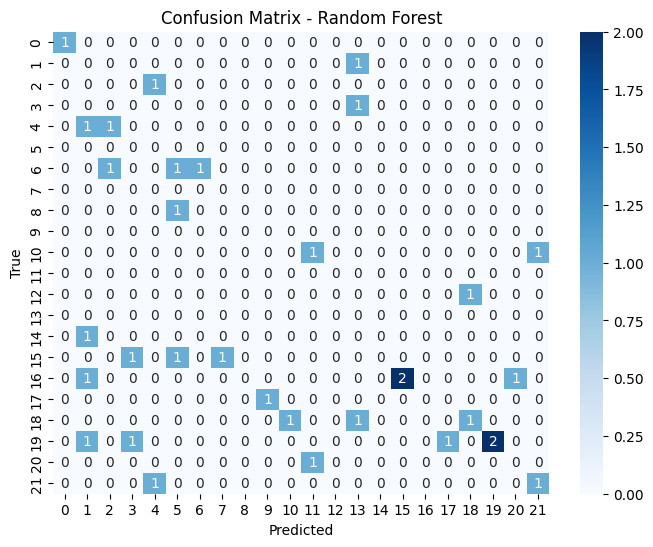


================= Logistic Regression =================
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         1
           3       0.00      0.00      0.00         1
           5       0.00      0.00      0.00         2
           7       1.00      0.33      0.50         3
           8       0.00      0.00      0.00         0
           9       0.00      0.00      0.00         0
          10       0.00      0.00      0.00         1
          12       0.00      0.00      0.00         2
          13       0.00      0.00      0.00         0
          14       1.00      1.00      1.00         1
          15       0.00      0.00      0.00         0
          16       0.00      0.00      0.00         1
          17       0.00      0.00      0.00         3
          18       0.00      0.00      0.00         4
 

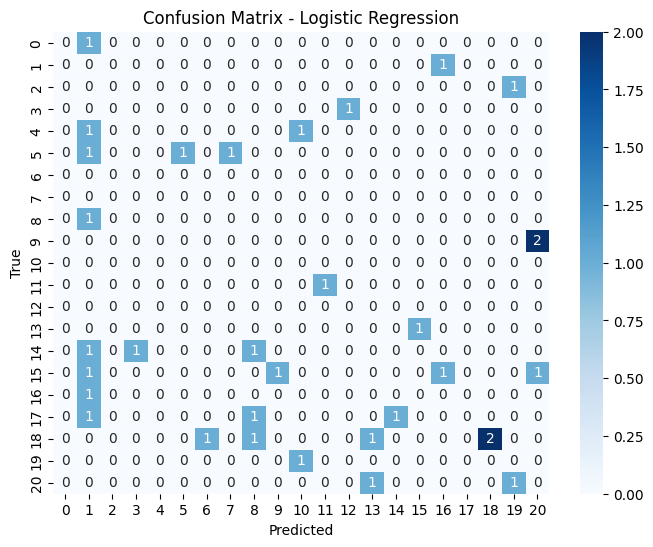


================= Decision Tree =================
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         1
           3       0.00      0.00      0.00         1
           5       0.00      0.00      0.00         2
           6       0.00      0.00      0.00         0
           7       1.00      0.33      0.50         3
           9       0.00      0.00      0.00         0
          10       0.00      0.00      0.00         1
          11       0.00      0.00      0.00         0
          12       0.00      0.00      0.00         2
          13       0.00      0.00      0.00         0
          14       0.00      0.00      0.00         1
          15       0.00      0.00      0.00         0
          16       0.00      0.00      0.00         1
          17       0.00      0.00      0.00         3
       

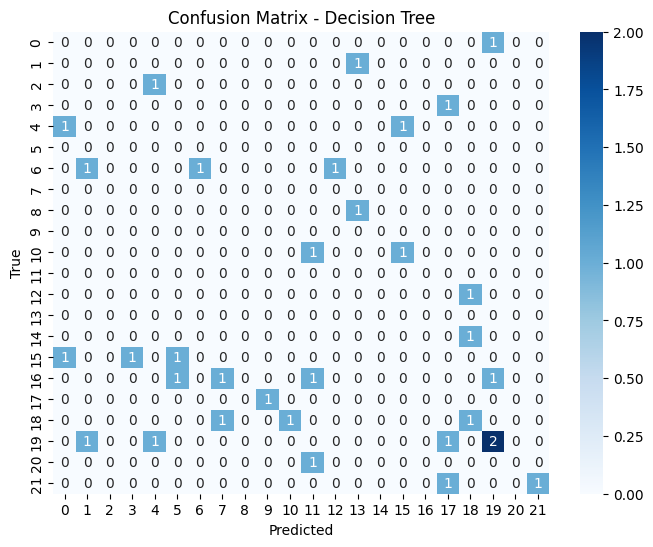


================= Support Vector Machine =================
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.03      1.00      0.06         1
           2       0.00      0.00      0.00         1
           3       0.00      0.00      0.00         1
           5       0.00      0.00      0.00         2
           7       0.00      0.00      0.00         3
          10       0.00      0.00      0.00         1
          12       0.00      0.00      0.00         2
          14       0.00      0.00      0.00         1
          16       0.00      0.00      0.00         1
          17       0.00      0.00      0.00         3
          18       0.00      0.00      0.00         4
          19       0.00      0.00      0.00         1
          20       0.00      0.00      0.00         3
          21       0.00      0.00      0.00         5
          22       0.00      0.00      0.00         

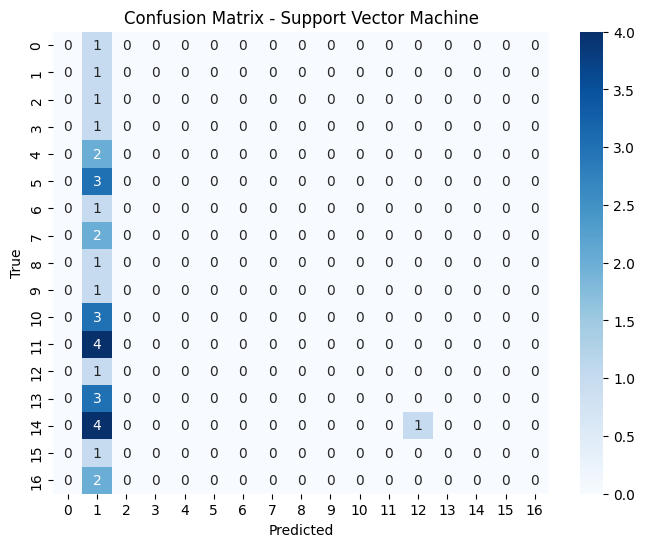

In [20]:
# 5. Training, Prediction, Confusion Matrix for each model
for name, model in models.items():
    print(f"\n================= {name} =================")
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Evaluation
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

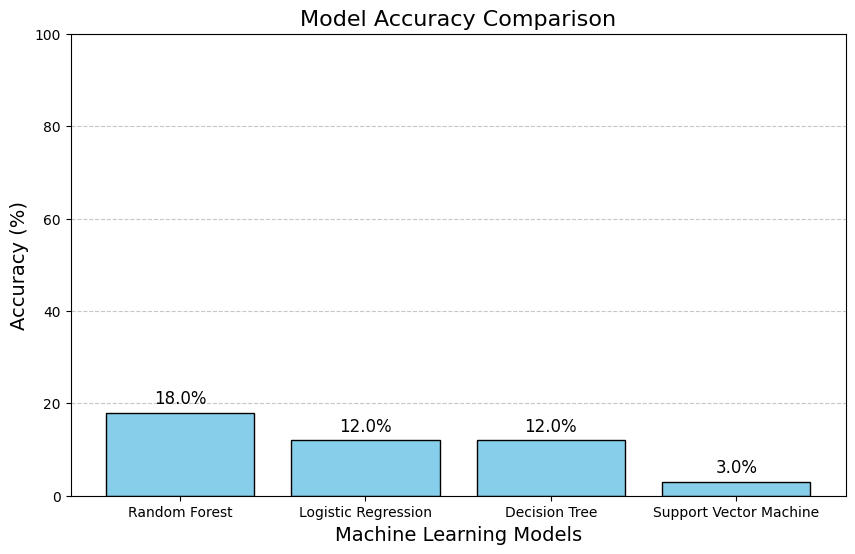

In [21]:
import matplotlib.pyplot as plt

# Accuracy scores you mentioned
accuracy_scores = {
    'Random Forest': 0.18,
    'Logistic Regression': 0.12,
    'Decision Tree': 0.12,
    'Support Vector Machine': 0.03
}

# Convert to percentage
accuracy_percentages = {model: score * 100 for model, score in accuracy_scores.items()}

# Plotting
plt.figure(figsize=(10,6))
plt.bar(accuracy_percentages.keys(), accuracy_percentages.values(), color='skyblue', edgecolor='black')
plt.title('Model Accuracy Comparison', fontsize=16)
plt.ylabel('Accuracy (%)', fontsize=14)
plt.xlabel('Machine Learning Models', fontsize=14)
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Annotate each bar with percentage value
for i, (model, acc) in enumerate(accuracy_percentages.items()):
    plt.text(i, acc + 2, f'{acc:.1f}%', ha='center', fontsize=12)

plt.show()


## Thanks pls upvote!!!!!